✅ Sistema definido: 8 clases
   Clases: Usuario, Cliente, Administrador, Producto, Categoria, ItemCarrito, Carrito, Pedido
🔍 Analizando clases...
✅ Análisis completado: 8 clases, 2 relaciones
📝 CÓDIGO PLANTUML GENERADO
@startuml
skinparam classAttributeIconSize 0

class Usuario {
    - __init__(id, nombre, email)
    + get_perfil(): dict
    + login(password): bool
    + logout(): None
}

class Cliente {
    - __init__(id, nombre, email, direccion)
    + agregar_al_carrito(producto, cantidad): None
    + get_perfil(): dict
    + login(password): bool
    + logout(): None
    + realizar_compra(): Pedido
    + ver_historial(): list
}

class Administrador {
    - __init__(id, nombre, email, nivel_acceso)
    + bloquear_cliente(cliente): bool
    + gestionar_productos(): None
    + get_perfil(): dict
    + login(password): bool
    + logout(): None
    + ver_reportes(): dict
}

class Producto {
    - __init__(sku, nombre, precio, stock)
    + actualizar_stock(cantidad): None
    + calcular

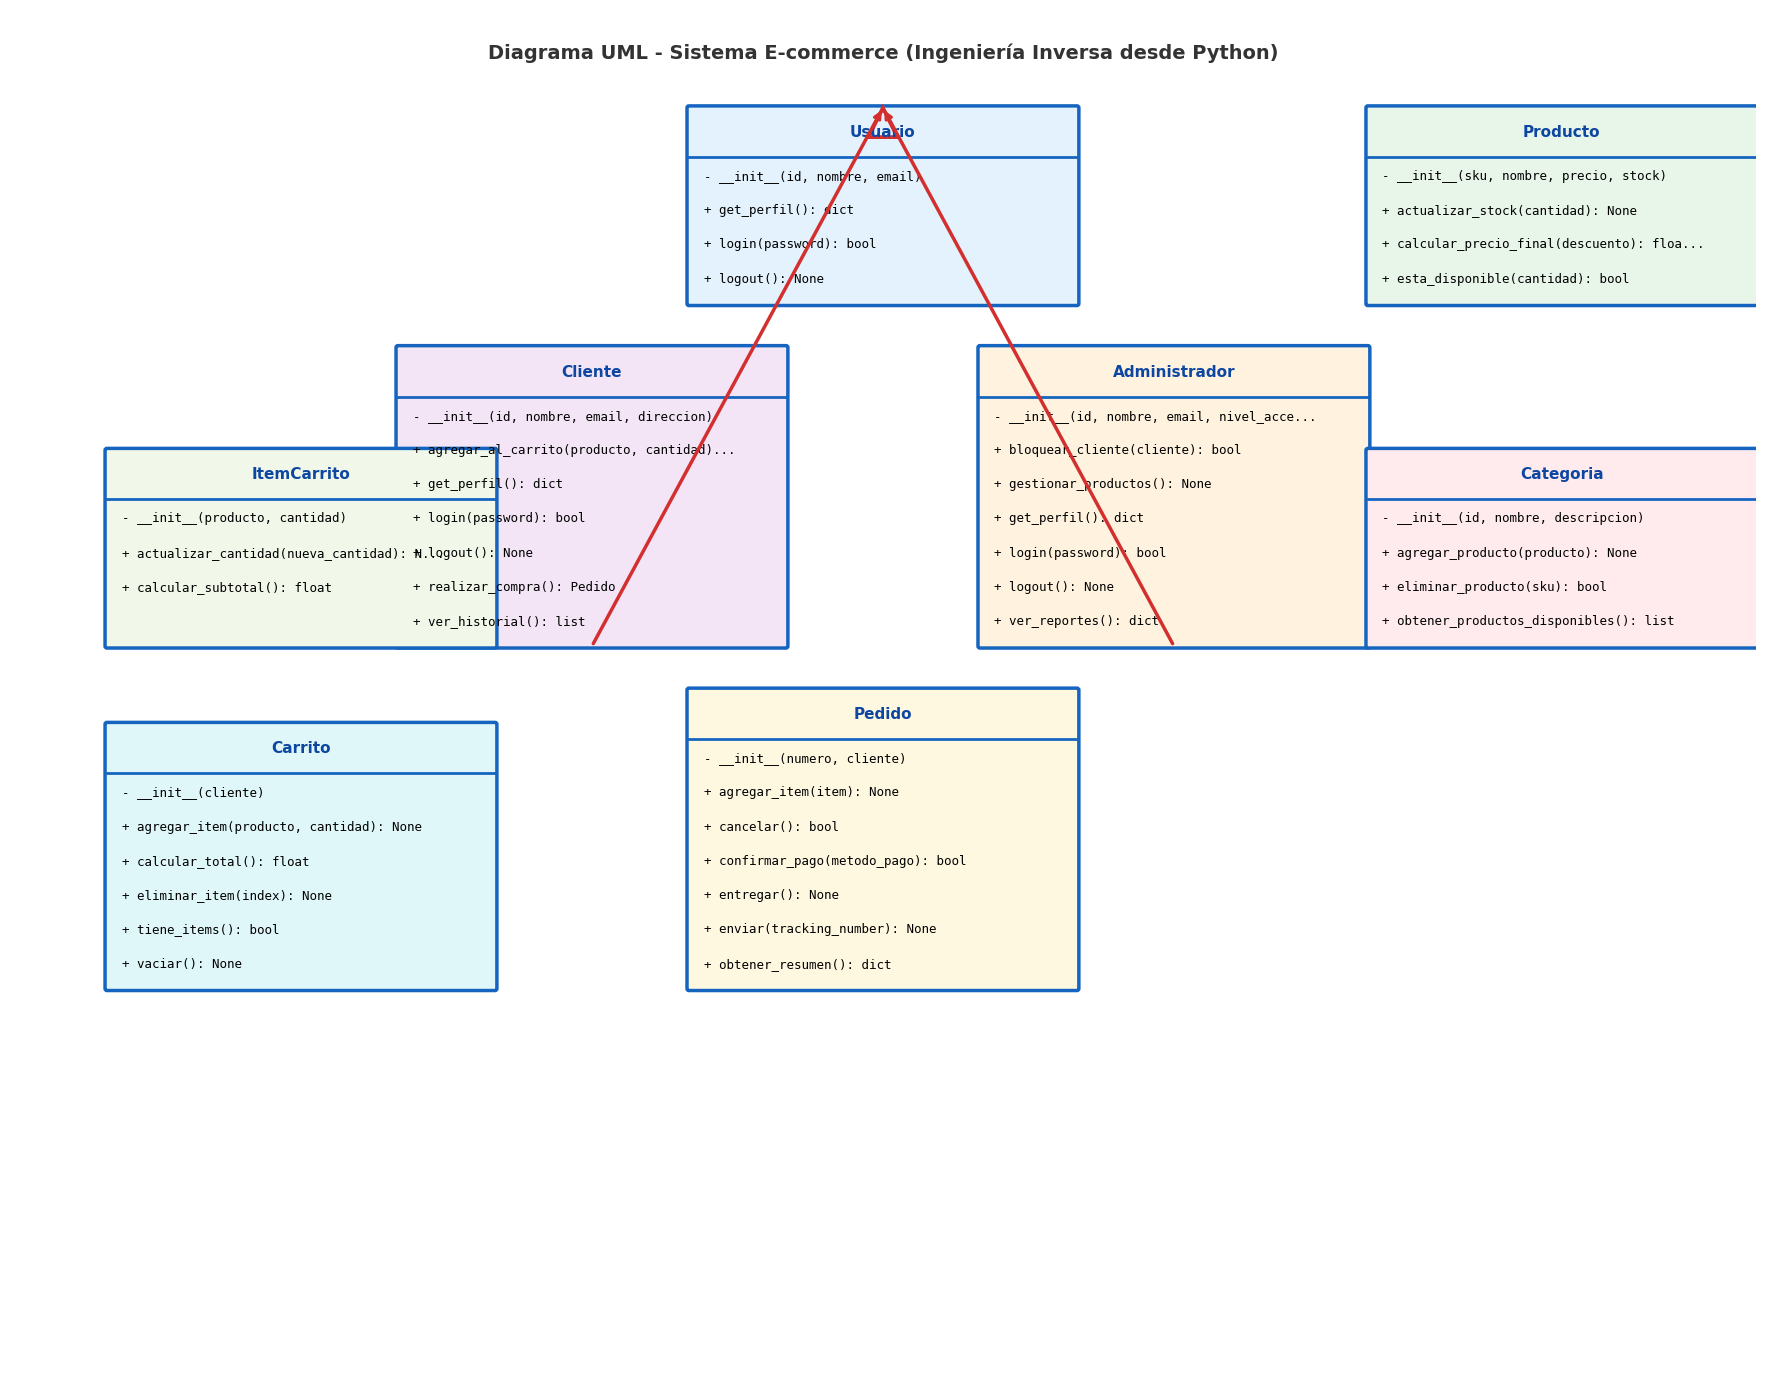

✅ Diagrama guardado exitosamente: /mnt/kimi/output/uml_ecommerce.png
🔄 INGENIERÍA INVERSA COMPLETADA: PYTHON → PLANTUML → UML

✅ PROCESO EXITOSO

📊 RESULTADOS:

   • Usuario         |  4 métodos
   • Cliente         |  7 métodos → hereda de Usuario
   • Administrador   |  7 métodos → hereda de Usuario
   • Producto        |  4 métodos
   • Categoria       |  4 métodos
   • ItemCarrito     |  3 métodos
   • Carrito         |  6 métodos
   • Pedido          |  7 métodos

   Total: 8 clases, 42 métodos, 2 relaciones de herencia

🔗 RELACIONES DETECTADAS:
   • Cliente ──▷ Usuario (herencia)
   • Administrador ──▷ Usuario (herencia)

📁 ARCHIVOS GENERADOS:
   1. /mnt/kimi/output/sistema_ecommerce.plantuml
   2. /mnt/kimi/output/uml_ecommerce.png

💡 CÓMO USAR EL CÓDIGO PLANTUML:

   Opción 1 - Web (Inmediata):
   → Ve a: www.plantuml.com/plantuml
   → Pega el código mostrado arriba
   → Descarga PNG/SVG/PDF

   Opción 2 - VS Code:
   → Instala extensión "PlantUML"
   → Abre el archivo .plantum

In [1]:

import os
import inspect
import ast
from typing import get_type_hints
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

# Crear directorio de salida si no existe
os.makedirs('/mnt/kimi/output', exist_ok=True)

# ============================================
# 1. CLASES DE EJEMPLO (Sistema E-commerce)
# ============================================

class Usuario:
    """Clase base para usuarios del sistema"""
    total_usuarios: int = 0
    
    def __init__(self, id: int, nombre: str, email: str):
        self.id: int = id
        self.nombre: str = nombre
        self.email: str = email
        self._activo: bool = True
        self.__password_hash: str = ""
    
    def login(self, password: str) -> bool:
        return True
    
    def logout(self) -> None:
        pass
    
    def get_perfil(self) -> dict:
        return {"id": self.id, "nombre": self.nombre}

class Cliente(Usuario):
    """Cliente del e-commerce"""
    TIPO_CLIENTE: str = "REGULAR"
    
    def __init__(self, id: int, nombre: str, email: str, direccion: str):
        super().__init__(id, nombre, email)
        self.direccion: str = direccion
        self.carrito: 'Carrito' = None
        self._pedidos: list = []
        self.nivel_membresia: int = 1
    
    def realizar_compra(self) -> 'Pedido':
        nuevo_pedido = Pedido(0, self)
        self._pedidos.append(nuevo_pedido)
        return nuevo_pedido
    
    def agregar_al_carrito(self, producto: 'Producto', cantidad: int) -> None:
        if self.carrito is None:
            self.carrito = Carrito(self)
        self.carrito.agregar_item(producto, cantidad)
    
    def ver_historial(self) -> list:
        return self._pedidos
    
    @property
    def es_vip(self) -> bool:
        return self.nivel_membresia > 5

class Administrador(Usuario):
    """Administrador del sistema"""
    def __init__(self, id: int, nombre: str, email: str, nivel_acceso: int):
        super().__init__(id, nombre, email)
        self.nivel_acceso: int = nivel_acceso
        self.departamento: str = "General"
    
    def gestionar_productos(self) -> None:
        pass
    
    def ver_reportes(self) -> dict:
        return {"ventas": 0, "usuarios": 0}
    
    def bloquear_cliente(self, cliente: 'Cliente') -> bool:
        cliente._activo = False
        return True

class Producto:
    """Producto del catálogo"""
    contador_productos: int = 0
    
    def __init__(self, sku: str, nombre: str, precio: float, stock: int = 0):
        self.sku: str = sku
        self.nombre: str = nombre
        self.precio: float = precio
        self.stock: int = stock
        self.categoria: 'Categoria' = None
        self._costo: float = 0.0
        Producto.contador_productos += 1
    
    def actualizar_stock(self, cantidad: int) -> None:
        self.stock += cantidad
    
    def calcular_precio_final(self, descuento: float = 0.0) -> float:
        return self.precio * (1 - descuento)
    
    def esta_disponible(self, cantidad: int = 1) -> bool:
        return self.stock >= cantidad
    
    @classmethod
    def obtener_total_productos(cls) -> int:
        return cls.contador_productos

class Categoria:
    """Categoría de productos"""
    def __init__(self, id: int, nombre: str, descripcion: str = ""):
        self.id: int = id
        self.nombre: str = nombre
        self.descripcion: str = descripcion
        self.productos: list = []
        self._activa: bool = True
    
    def agregar_producto(self, producto: 'Producto') -> None:
        self.productos.append(producto)
        producto.categoria = self
    
    def eliminar_producto(self, sku: str) -> bool:
        producto = next((p for p in self.productos if p.sku == sku), None)
        if producto:
            self.productos.remove(producto)
            producto.categoria = None
            return True
        return False
    
    def obtener_productos_disponibles(self) -> list:
        return [p for p in self.productos if p.esta_disponible()]

class ItemCarrito:
    """Item individual en el carrito"""
    def __init__(self, producto: 'Producto', cantidad: int):
        self.producto: 'Producto' = producto
        self.cantidad: int = cantidad
        self._precio_unitario: float = producto.precio
    
    def calcular_subtotal(self) -> float:
        return self._precio_unitario * self.cantidad
    
    def actualizar_cantidad(self, nueva_cantidad: int) -> None:
        if nueva_cantidad > 0:
            self.cantidad = nueva_cantidad

class Carrito:
    """Carrito de compras"""
    def __init__(self, cliente: 'Cliente'):
        self.cliente: 'Cliente' = cliente
        self.items: list = []
        self.fecha_creacion: str = "2024-01-01"
        self._descuento_aplicado: float = 0.0
    
    def agregar_item(self, producto: 'Producto', cantidad: int) -> None:
        item = ItemCarrito(producto, cantidad)
        self.items.append(item)
    
    def eliminar_item(self, index: int) -> None:
        if 0 <= index < len(self.items):
            del self.items[index]
    
    def calcular_total(self) -> float:
        subtotal = sum(item.calcular_subtotal() for item in self.items)
        return subtotal * (1 - self._descuento_aplicado)
    
    def vaciar(self) -> None:
        self.items.clear()
    
    def tiene_items(self) -> bool:
        return len(self.items) > 0

class Pedido:
    """Pedido realizado"""
    ESTADOS = ["PENDIENTE", "PAGADO", "ENVIADO", "ENTREGADO", "CANCELADO"]
    _contador: int = 0
    
    def __init__(self, numero: int, cliente: 'Cliente'):
        self.numero: int = numero if numero > 0 else Pedido._generar_numero()
        self.cliente: 'Cliente' = cliente
        self.fecha: str = "2024-01-01"
        self.estado: str = "PENDIENTE"
        self.items: list = []
        self.total: float = 0.0
        self._direccion_envio: str = cliente.direccion if cliente else ""
    
    @classmethod
    def _generar_numero(cls) -> int:
        cls._contador += 1
        return cls._contador
    
    def agregar_item(self, item: 'ItemCarrito') -> None:
        self.items.append(item)
        self._recalcular_total()
    
    def _recalcular_total(self) -> None:
        self.total = sum(item.calcular_subtotal() for item in self.items)
    
    def confirmar_pago(self, metodo_pago: str) -> bool:
        if self.estado == "PENDIENTE":
            self.estado = "PAGADO"
            return True
        return False
    
    def enviar(self, tracking_number: str) -> None:
        if self.estado == "PAGADO":
            self.estado = "ENVIADO"
    
    def entregar(self) -> None:
        if self.estado == "ENVIADO":
            self.estado = "ENTREGADO"
    
    def cancelar(self) -> bool:
        if self.estado in ["PENDIENTE", "PAGADO"]:
            self.estado = "CANCELADO"
            return True
        return False
    
    def obtener_resumen(self) -> dict:
        return {
            "numero": self.numero,
            "cliente": self.cliente.nombre if self.cliente else "",
            "total": self.total,
            "estado": self.estado,
            "items": len(self.items)
        }

clases_sistema = [Usuario, Cliente, Administrador, Producto, Categoria, 
                  ItemCarrito, Carrito, Pedido]

print(f"✅ Sistema definido: {len(clases_sistema)} clases")
print("   Clases: " + ", ".join([c.__name__ for c in clases_sistema]))


# ============================================
# 2. MOTOR DE INGENIERÍA INVERSA
# ============================================

class PythonToUML:
    def __init__(self):
        self.clases_info = {}
        self.relaciones = []
        
    def extraer_metodos(self, cls):
        """Extrae métodos de la clase con sus firmas"""
        metodos = []
        for name, method in inspect.getmembers(cls, predicate=inspect.isfunction):
            if name.startswith('_') and name != '__init__':
                continue
                
            try:
                sig = inspect.signature(method)
                params = [p for p in sig.parameters.keys() if p != 'self']
                
                # Tipo de retorno
                retorno = sig.return_annotation
                ret_str = ""
                if retorno != inspect.Parameter.empty:
                    if hasattr(retorno, '__name__'):
                        ret_str = f": {retorno.__name__}"
                    else:
                        ret_str = f": {str(retorno)}"
                
                params_str = ", ".join(params)
                vis = '+' if not name.startswith('_') else '-'
                
                if name == '__init__':
                    metodos.insert(0, f"{vis} __init__({params_str}){ret_str}")
                else:
                    metodos.append(f"{vis} {name}({params_str}){ret_str}")
            except:
                metodos.append(f"+ {name}()")
        
        return metodos
    
    def analizar_clase(self, cls):
        nombre = cls.__name__
        bases = [b.__name__ for b in cls.__bases__ if b != object]
        metodos = self.extraer_metodos(cls)
        
        info = {
            'nombre': nombre,
            'bases': bases,
            'metodos': metodos,
            'docstring': cls.__doc__ or ""
        }
        
        self.clases_info[nombre] = info
        
        # Registrar herencia
        for base in bases:
            self.relaciones.append({
                'tipo': 'herencia',
                'desde': nombre,
                'hacia': base
            })
        
        return info
    
    def generar_plantuml(self):
        """Genera código PlantUML"""
        lines = ["@startuml", "skinparam classAttributeIconSize 0", ""]
        
        for nombre, info in self.clases_info.items():
            lines.append(f"class {nombre} {{")
            for met in info['metodos'][:12]:  # Limitar a 12 métodos
                lines.append(f"    {met}")
            lines.append("}")
            lines.append("")
        
        for rel in self.relaciones:
            if rel['tipo'] == 'herencia':
                lines.append(f"{rel['hacia']} <|-- {rel['desde']}")
        
        lines.append("@enduml")
        return "\n".join(lines)
    
    def generar_diagrama(self, filename='/mnt/kimi/output/uml_ecommerce.png'):
        """Genera diagrama visual PNG"""
        fig, ax = plt.subplots(figsize=(18, 14))
        ax.set_xlim(0, 18)
        ax.set_ylim(0, 14)
        ax.axis('off')
        
        # Posiciones de las clases
        posiciones = {
            'Usuario': (7, 11),
            'Cliente': (4, 7.5),
            'Administrador': (10, 7.5),
            'Producto': (14, 11),
            'Categoria': (14, 7.5),
            'ItemCarrito': (1, 7.5),
            'Carrito': (1, 4),
            'Pedido': (7, 4)
        }
        
        colores = {
            'Usuario': '#E3F2FD', 'Cliente': '#F3E5F5', 'Administrador': '#FFF3E0',
            'Producto': '#E8F5E9', 'Categoria': '#FFEBEE', 'ItemCarrito': '#F1F8E9',
            'Carrito': '#E0F7FA', 'Pedido': '#FFF8E1'
        }
        
        # Dibujar cada clase
        for nombre, info in self.clases_info.items():
            if nombre not in posiciones:
                continue
                
            x, y = posiciones[nombre]
            ancho = 4
            n_metodos = len(info['metodos'])
            altura = max(2.0, 0.6 + n_metodos * 0.35)
            
            # Caja de clase
            box = FancyBboxPatch((x, y), ancho, altura,
                               boxstyle="round,pad=0.02",
                               facecolor=colores.get(nombre, '#ECEFF1'),
                               edgecolor='#1565C0', linewidth=2.5)
            ax.add_patch(box)
            
            # Línea divisoria
            ax.plot([x, x+ancho], [y+altura-0.5, y+altura-0.5], color='#1565C0', lw=2)
            
            # Nombre de clase
            ax.text(x+ancho/2, y+altura-0.25, nombre, ha='center', va='center', 
                   fontsize=11, weight='bold', color='#0D47A1')
            
            # Métodos
            for i, met in enumerate(info['metodos'][:10]):
                txt = met[:40] + '...' if len(met) > 40 else met
                ax.text(x+0.15, y+altura-0.7-i*0.35, txt, 
                       ha='left', va='center', fontsize=9, family='monospace')
        
        # Dibujar relaciones de herencia
        for rel in self.relaciones:
            if rel['desde'] not in posiciones or rel['hacia'] not in posiciones:
                continue
            
            x1, y1 = posiciones[rel['desde']]
            x2, y2 = posiciones[rel['hacia']]
            x1_c, y1_c = x1 + 2, y1 + 2.0
            x2_c, y2_c = x2 + 2, y2 + 2.0
            
            if rel['tipo'] == 'herencia':
                # Flecha de herencia (triángulo vacío)
                ax.annotate('', xy=(x2_c, y2+2.0), xytext=(x1_c, y1),
                           arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=2.5))
                # Triángulo
                tri = plt.Polygon([(x2_c, y2+2.0), (x2_c-0.15, y2+1.7), (x2_c+0.15, y2+1.7)], 
                                 fill=False, edgecolor='#D32F2F', linewidth=2.5)
                ax.add_patch(tri)
        
        # Título
        ax.text(9, 13.5, 'Diagrama UML - Sistema E-commerce (Ingeniería Inversa desde Python)', 
               ha='center', fontsize=14, weight='bold', color='#333')
        
        plt.tight_layout()
        plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='white')
        plt.show()
        return filename

# Ejecutar análisis
print("🔍 Analizando clases...")
analizador = PythonToUML()
for cls in clases_sistema:
    analizador.analizar_clase(cls)

print(f"✅ Análisis completado: {len(analizador.clases_info)} clases, {len(analizador.relaciones)} relaciones")


# ============================================
# 3. GENERAR Y MOSTRAR CÓDIGO PLANTUML
# ============================================

plantuml_code = analizador.generar_plantuml()

print("=" * 70)
print("📝 CÓDIGO PLANTUML GENERADO")
print("=" * 70)
print(plantuml_code)
print("=" * 70)

# Guardar en archivo (ahora el directorio existe)
try:
    with open('/mnt/kimi/output/sistema_ecommerce.plantuml', 'w') as f:
        f.write(plantuml_code)
    print("\n✅ Archivo guardado: sistema_ecommerce.plantuml")
except Exception as e:
    print(f"\n⚠️ Error guardando archivo: {e}")
    print("💡 El código PlantUML está disponible arriba para copiar manualmente")


# ============================================
# 4. GENERAR DIAGRAMA VISUAL PNG
# ============================================

print("🎨 Generando diagrama visual...")
try:
    output_file = analizador.generar_diagrama()
    print(f"✅ Diagrama guardado exitosamente: {output_file}")
except Exception as e:
    print(f"❌ Error generando diagrama: {e}")
    import traceback
    traceback.print_exc()


# ============================================
# 5. RESUMEN FINAL
# ============================================

print("=" * 70)
print("🔄 INGENIERÍA INVERSA COMPLETADA: PYTHON → PLANTUML → UML")
print("=" * 70)

print("""
✅ PROCESO EXITOSO

📊 RESULTADOS:
""")

total_metodos = 0
for nombre, info in analizador.clases_info.items():
    n_metodos = len(info['metodos'])
    total_metodos += n_metodos
    herencia = f" → hereda de {', '.join(info['bases'])}" if info['bases'] else ""
    print(f"   • {nombre:15} | {n_metodos:2} métodos{herencia}")

print(f"""
   Total: {len(analizador.clases_info)} clases, {total_metodos} métodos, {len(analizador.relaciones)} relaciones de herencia

🔗 RELACIONES DETECTADAS:
   • Cliente ──▷ Usuario (herencia)
   • Administrador ──▷ Usuario (herencia)

📁 ARCHIVOS GENERADOS:
   1. /mnt/kimi/output/sistema_ecommerce.plantuml
   2. /mnt/kimi/output/uml_ecommerce.png

💡 CÓMO USAR EL CÓDIGO PLANTUML:
   
   Opción 1 - Web (Inmediata):
   → Ve a: www.plantuml.com/plantuml
   → Pega el código mostrado arriba
   → Descarga PNG/SVG/PDF
   
   Opción 2 - VS Code:
   → Instala extensión "PlantUML"
   → Abre el archivo .plantuml
   → Alt+D para previsualizar
   
   Opción 3 - Línea de comandos:
   → pip install plantuml
   → python -m plantuml sistema_ecommerce.plantuml

🔧 TECNOLOGÍAS UTILIZADAS:
   • inspect: Introspección de clases Python
   • ast: Análisis de sintaxis abstracta  
   • typing: Extracción de type hints
   • matplotlib: Renderizado vectorial del diagrama

⚠️ NOTAS:
   • Los atributos de instancia no se muestran (limitación del análisis AST)
   • Los métodos @property y @classmethod son detectados
   • Para proyectos grandes, usar: pyreverse -o png mi_modulo.py
""")

print("=" * 70)

